<a href="https://colab.research.google.com/github/vmlprado-code/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as  pd
import seaborn as  sns
import matplotlib.pyplot as  plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("Cantidad de valores nulos en users")
print(users.isna().sum())
print()
print("Proporción de valores nulos en users")
print(users.isna().mean())

Cantidad de valores nulos en users
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos en users
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
print("Cantidad de valores nulos en usage")
print(usage.isna().sum())
print()

print(print("Proporción de valores nulos en usage"))
print(usage.isna().mean())

Cantidad de valores nulos en usage
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos en usage
None
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
    - users: city= 11.72% , churn_date= 88.35%
    - usage: date = 0.1% , duration= 55.19% , length= 44.74%
- Indica qué harías: ¿imputar, eliminar, ignorar?
    - users: city= 11.72% investigar para identificar segmentacion geografica, churn_date= 88.35% posiblemnte ignorar, ya que el chur es fundamental entender  por que es la salida de los clientes potenciales.
    - usage: date = 0.1% eliminar son 50 registros, duration= 55.19% , length= 44.74%, investigar ya que  podemos idear planes que ajusten a su consumo de uso.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` columna de asignacion de id para identificar  al usuario, no tine mucha relevancia mas allá de un count media y median pegadas "identicas" no hay nulos a primera vista no hay daotos sopechosos,
- La columna `age` se detectan outlier en parametro "min", ya que  el valos minimo no puede ser <=0, esto esta afectando a al media a la std, genernado un sesgo a la derech, se deb explorar cuantos outlier son y evaluar su tratamiento.

In [ ]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id`y `user_id`son columnas de codigo de id, sin mucha relevancia más allá de un count, no se visualiza dato nulos, media y median alineadas  asi como los q1,q2,q3
- Las columnas 'duration'  y presenta una mayor dispersion de datos la cual es por le Quartil MAX´ya que  esta en ambas presenta un distanciamiento considerable del  Q3, moviendo mean, std y generando sesgo a la derecha.

In [ ]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']]
columnas_user.describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` cuentas con 7 localidades unicas en latam (para  2024)siendo bogota la top con una frecuencia de 808, con 467 datos nulos o faltantes
- La columna `plan` solo tiene  2 tipos de planes, siendo el basico el ms contratado con una frecuencia de 2595, no hay datos nulos o faltantes

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` cuenta con 2 uncas categorias unicas, siendo "texto"  la top con una frecuenciqa de 22,092, no existe valores nulos o faltantes


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
   R= en columna "users.age", se detecta sentinels -999, esto no es posible ya que el minimo no puede ser <=0, afectando a la media y std,  genernado un sesgo
      de igual forma se detectan valores extremos  en max en la columnas usage["duration","length"], afectando a la media y  std generando sesgos
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"])

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`,datos de años pasado que no son objeto de estudio en el analisis y  datos incorrectos ya que son 2026 y el df  es hasta el 2024.

In [ ]:
# Revisar los años presentes en `date` de usage

usage['date'].dt.year.unique()
usage['date'].dt.year.value_counts()


2024.0    39950
Name: date, dtype: int64


En `date`, solo se visualiza año 2024, en el primer analis  exploratorio se detecto que existen  50 NaN los cuales represntan en  0.1% los cuales de momento podemos ignorar ya que  puedes estar relacionado con otras columnas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?
  R= se muestran años imposible  no transcurridos ya que el df  de user es solo hasta el 2024  y hay registros en  reg_date con año  "2026"
- ¿Qué harías con ellas? con los años 2022,2023 elimnar con drop ya que no son objeto de estudio. con los 2026 de momenot podemos ignoralos ya que no sabesmos si hay alguna relacion con otra columna, si mas adelante se encuentra podemos dejrlos nulos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users["city"]=users["city"].replace("?", pd.NA)


users["city"].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year == 2026, "reg_date"]= pd.NaT

# Verificar cambios
users['reg_date'].dt.year.unique()




array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)# Verificación MAR en usage (Missing At Random) para duration


type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False) #Verificación MAR en usage (Missing At Random) para length


type
call    0.99933
text    0.00000
Name: length, dtype: float64

son erroneos, ya que no hay logica de que duracion de un mensje de texto  o la longuitud  de llamada, pero puede visualizarse con otra columna que  es type y por consecuente s epuede considerar en ambos casos MAR, por el alto numero de datos de momento los dejarimos como nulos, ya que pueden influir en un dato de revenue

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby(["user_id"])[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas


usage_agg.rename(columns={"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada"}, inplace=True)



# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users, on="user_id", how="inner")
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:

columnas_numericas = user_profile[user_profile["reg_date"].dt.year == 2024][["cant_mensajes", "cant_llamadas", "cant_minutos_llamada","age"]]
print("Resumen estadístico de las columnas numéricas")
print(columnas_numericas.describe())
print()
columnas_numericas.info()





Resumen estadístico de las columnas numéricas
       cant_mensajes  cant_llamadas  cant_minutos_llamada          age
count    1330.000000    1330.000000           1330.000000  1330.000000
mean        5.500000       4.557143             24.126669    48.414286
std         2.382293       2.140329             19.458620    17.963443
min         0.000000       0.000000              0.000000    18.000000
25%         4.000000       3.000000             11.332500    33.000000
50%         5.000000       4.000000             20.325000    48.000000
75%         7.000000       6.000000             32.542500    64.000000
max        16.000000      13.000000            155.690000    79.000000

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1330 entries, 2665 to 3998
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cant_mensajes         1330 non-null   int64  
 1   cant_llamadas         1330 non-null   int64  
 

In [ ]:

columna_categorica = user_profile[user_profile["reg_date"].dt.year == 2024]["plan"]

print("Distribución porcentual del tipo de plan")

columna_categorica.value_counts(normalize=True) * 100



Distribución porcentual del tipo de plan


Basico     65.639098
Premium    34.360902
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

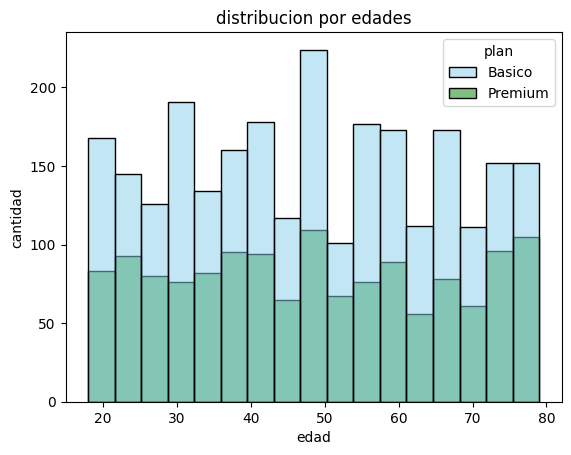

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age",hue='plan', palette=['skyblue','green'])
plt.title("distribucion por edades")
plt.xlabel("edad")
plt.ylabel("cantidad")
plt.show()

💡Insights:
hay mayor proporcion de  usuarios en rango de 50  años,  para plan premium los rango de 50 y 80, son los usurios con mayor proporcion. y para el plan basico nuevamente  el rango de 5 años junto con el rango de 30 años  son los que cuentan con mayor  porcion"
- existe  una distribución plana y simetrica, con diverso picos., nos prmiet ver los grangos  de clientes por edades y comportamienot de contratacion del tipo de plan

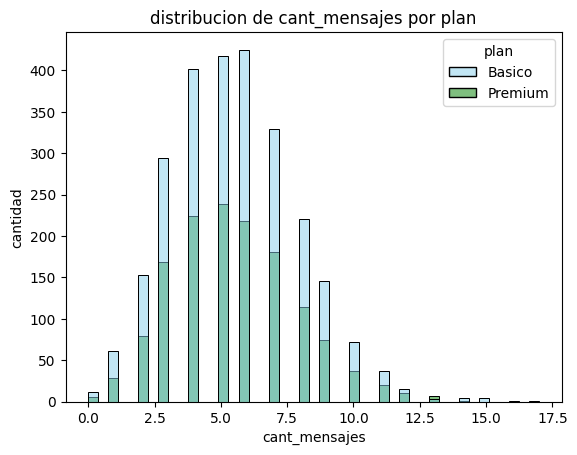

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes",hue='plan', palette=['skyblue','green'])
plt.title("distribucion de cant_mensajes por plan")
plt.xlabel("cant_mensajes")
plt.ylabel("cantidad")
plt.show()


💡Insights:
- distribucion con sesgo a la derecha, siendo el pico mas alto 5, presenta mayor porcion en plan premiun 5 y en plan basico 6, esto nos permite  entender  la tendecia de uso de los servicios que  ofrece por tipo de plan

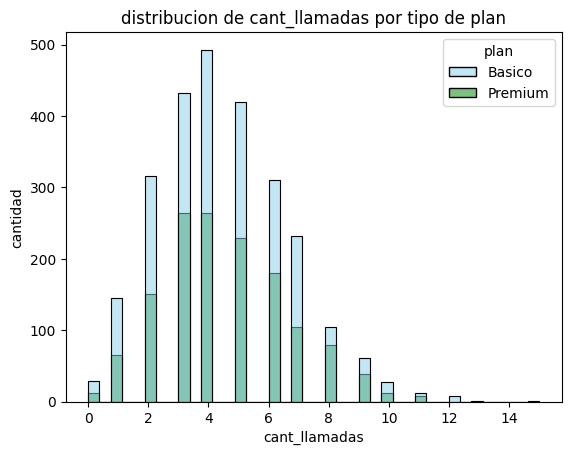

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas",hue='plan', palette=['skyblue','green'])
plt.title("distribucion de cant_llamadas por tipo de plan")
plt.xlabel("cant_llamadas")
plt.ylabel("cantidad")
plt.show()

💡Insights:
- Distribución sesgo a la derecha, siendo la porcion más 3-4 llamdas alta de numero de llamadas realizadas dentro del plan premium

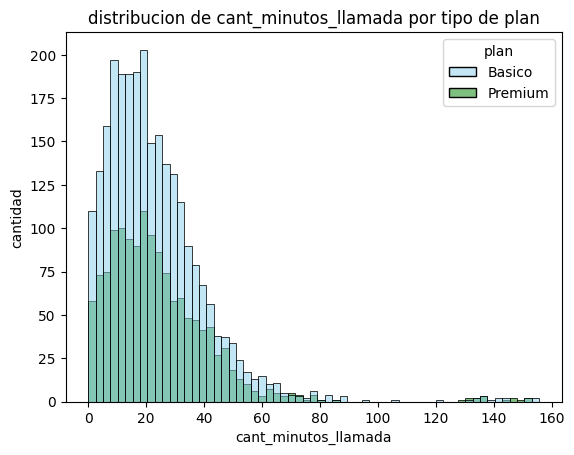

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada",hue='plan', palette=['skyblue','green'])
plt.title("distribucion de cant_minutos_llamada por tipo de plan")
plt.xlabel("cant_minutos_llamada")
plt.ylabel("cantidad")
plt.show()


💡Insights:
 distribuon muy marcada con sego a la derecha, con mayor porcion en el rango de 20  minutos tanto en plan premiun como basico, existe posibles outliers  en valore entre 120-160 minutos.
 si realizamos una compartivo entre  cantidas de llamadas, minutos y menaje, se podria realizar ajustes e plenes  mas atractivos   para un incremento de  captacion de clientes/ usurios

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

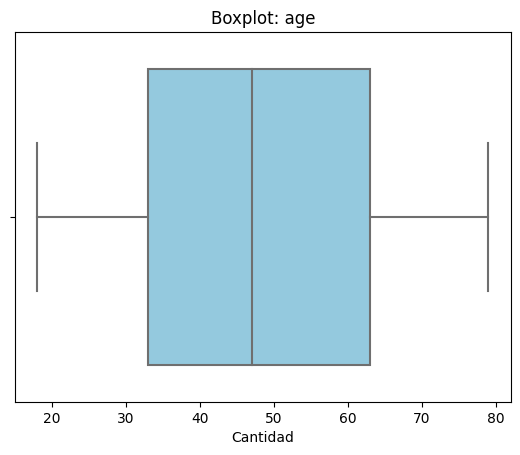

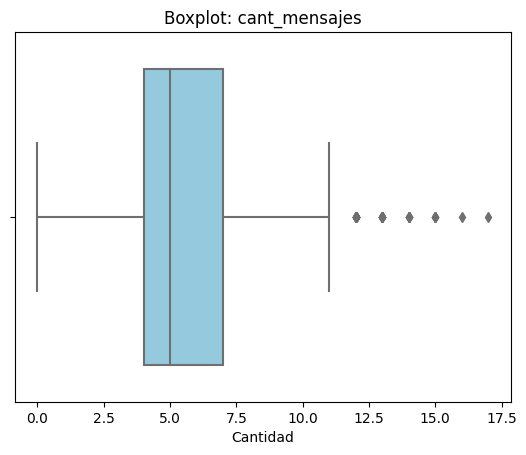

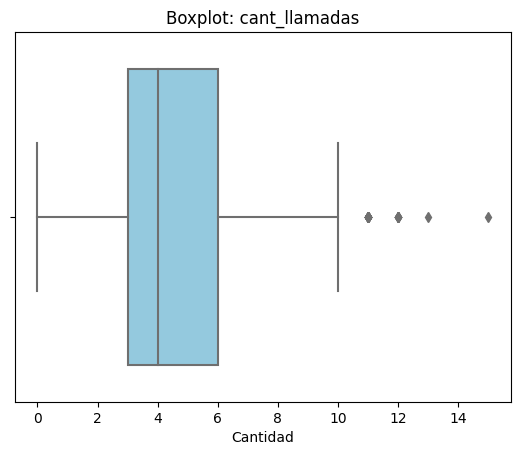

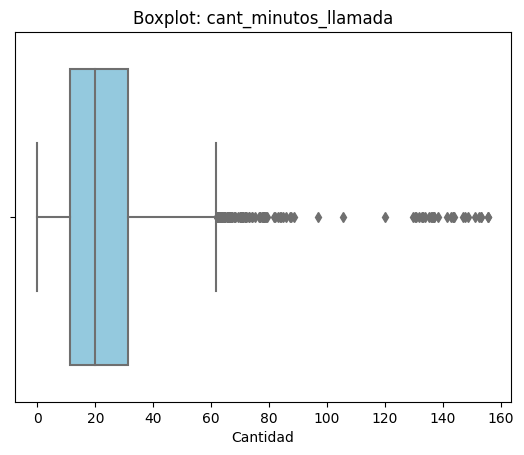

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')

    plt.title(f'Boxplot: {col}')
    plt.xlabel('Cantidad')
    plt.show()


💡Insights:
- Age: no presenta outlier, con una distribucion simetrica
- cant_mensajes: se detectan 6 datos outliers de 12.  a 17  mensaje, puede que sea tendencia de usuarios por whatsapp
- cant_llamadas: posibles outlier entre 11 a 15 llamadas,  se marca posible ya que estos usuarios pueden tener mayor t4endencia e uso del servicio de llamadas
- cant_minutos_llamada: alto nivel de outlier, ya que  poco probable  conversaciones de >60 min

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ["cant_minutos_llamada","cant_llamadas", "cant_mensajes"]

resultado = []

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1


    lower  = Q1 - (1.5 * IQR)
    upper  = Q3 + (1.5 * IQR)

    resultado.append({
        "Columna": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower ": lower ,
        "upper ": upper
    })

iqr_columns = pd.DataFrame(resultado)

print(iqr_columns)


                Columna     Q1      Q3     IQR   lower    upper 
0  cant_minutos_llamada  11.12  31.415  20.295 -19.3225  61.8575
1         cant_llamadas   3.00   6.000   3.000  -1.5000  10.5000
2         cant_mensajes   4.00   7.000   3.000  -0.5000  11.5000


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_minutos_llamada,cant_llamadas,cant_mensajes
count,3999.000000,3999.000000,3999.000000
mean,23.317054,4.478120,5.524381
std,18.168095,2.144238,2.358416
min,0.000000,0.000000,0.000000
25%,11.120000,3.000000,4.000000
50%,19.780000,4.000000,5.000000
75%,31.415000,6.000000,7.000000
max,155.690000,15.000000,17.000000


💡Insights:
se calcularon los limites lower y upper, donde lower sera un un valor absoluto =0 y upper  se real el limite  de partida para descartar outlier, esto para  estabilizar la media y tener una distribucion mas simetrica
- cant_mensajes: se recomienoda mantener y  capar no eliminar, para teenr una distribucion simetrica esto con el fin de tener mayo universo de analisis
- cant_llamadas: se recomienoda  mantener y capar no eliminar, para teenr una distribucion simetrica esto con el fin de tener mayo universo de analisis
- cant_minutos_llamada: eliminar, afecta al promedio rango muy lejanos del de limite superior  "upper", afecta al analisis



## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso




def clasificar_uso(row):
    llamadas = row["cant_llamadas"]
    mensajes = row["cant_mensajes"]

    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"

    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"

    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(clasificar_uso, axis=1)
print(user_profile["grupo_uso"].value_counts())


Uso medio    2943
Bajo uso      778
Alto uso      278
Name: grupo_uso, dtype: int64


In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def edades (row):
    edad = row["age"]

    if edad < 30:
        return "Joven"

    elif edad < 60:
        return "Adulto"

    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(edades, axis=1)
print(user_profile["grupo_edad"].value_counts())


Adulto          2017
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

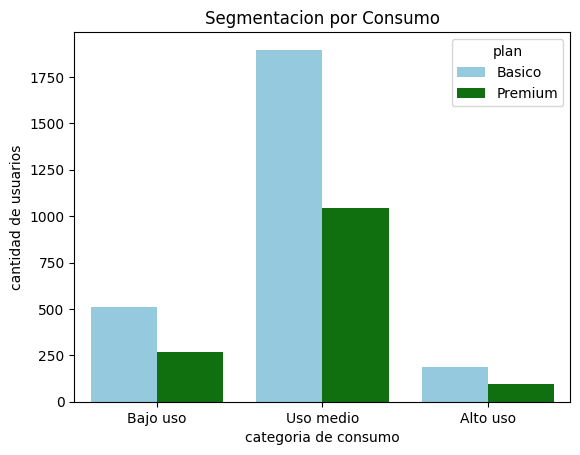

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data= user_profile, x="grupo_uso", hue= "plan", order=["Bajo uso", "Uso medio", "Alto uso"], palette=['skyblue','green', "orange"])
plt.title("Segmentacion por Consumo")
plt.xlabel("categoria de consumo")
plt.ylabel("cantidad de usuarios")
plt.show()

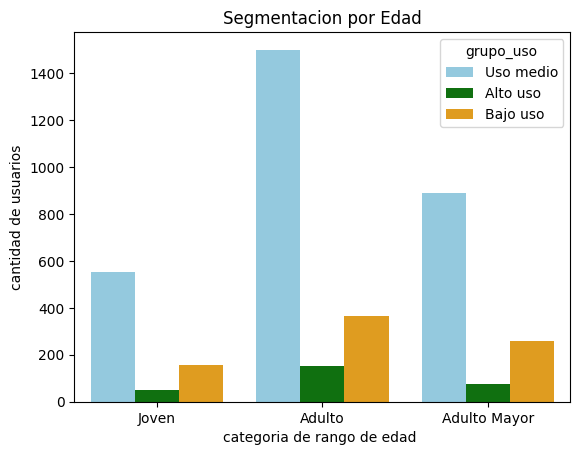

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data= user_profile, x="grupo_edad", hue ="grupo_uso", order=["Joven", "Adulto", "Adulto Mayor"], palette=['skyblue','green', "orange"])
plt.title("Segmentacion por Edad")
plt.xlabel("categoria de rango de edad ")
plt.ylabel("cantidad de usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
 - ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Para el desarrollo de este proyecto se utilizaron tres conjuntos de datos: plans, users y usage. El DataFrame usage contiene aproximadamente 40,000 registros sobre el comportamiento de uso de los clientes de Connecta Tel durante el periodo 2022–2026. No obstante, para este análisis se filtró la información correspondiente únicamente al año 2024, con el fin de trabajar sobre un periodo homogéneo.
Durante el Análisis Exploratorio de Datos (EDA) se identificaron diversos problemas de calidad que requerían un proceso de limpieza y estandarización antes de continuar con el análisis.

Columna con datos nulos ,  siendo en los df users ["city", "churrn"], esage ["date", duration", "leagth"], city = 469 = 11.72%, churrn = 3534 = 88.35 date = 50 = 0.125%, duration = 22076 = 55.19% , length = 17896 = 44.74%

Las columnas date, duration y length son fundamentales para el análisis del comportamiento de los usuarios, ya que permiten conocer la frecuencia, duración y volumen de consumo de los servicios. Debido a su importancia, fue necesario aplicar un proceso de limpieza de datos para corregir inconsistencias, estandarizar los registros y definir un tratamiento adecuado para los valores faltantes.

Durante la exploración también se detectaron valores atípicos que podían afectar la calidad de los resultados:
ege = -999  sentinels que se corrije, en duration y lenght valores extremos muy lejanos a los rangos de IQR , esto puede ser un datos erroneos  y/o atipicos, afectan al analisis del negocio.

🔍 **Segmentos por Edad**

Se realizó una segmentación de los usuarios por grupos de edad, definiendo tres categorías:"Joven" de <30, "Adulto" <60 & "Adulto Mayor" >60. El análisis mostró que la categoría Adulto concentra la mayor proporción de usuarios de Connecta Tel. Asimismo, este grupo presenta la mayor participación en los niveles de uso medio y uso bajo, lo que indica que la mayoría de los clientes pertenecen a este segmento y mantienen un patrón de consumo.

En contraste, el nivel de uso alto representa una proporción considerablemente menor dentro de todos los grupos de edad, lo que sugiere que el consumo intensivo del servicio es un comportamiento menos frecuente entre los clientes.

📊 **Segmentos por Nivel de Uso**

En el análisis de los niveles de uso durante 2024, se observó que la categoría de uso medio concentra la mayor proporción de clientes. Dentro de este segmento, el plan Básico es el más representativo, con aproximadamente 1,800 usuarios, mientras que el plan Premium registra cerca de 1,000 usuarios. Estos resultados indican que la mayor parte de la base de clientes mantiene un nivel de consumo moderado y que el plan Básico es la opción predominante entre los usuarios con este patrón de uso.

➡️ Esto sugiere que

El análisis muestra que la categoría de uso medio es predominante entre los usuarios del plan Básico menores de 60 años. Este segmento concentra la mayor parte de los clientes, convirtiéndose en la base más sólida de la cartera de Connecta Tel durante el periodo analizado. Su alta participación lo posiciona como un grupo estratégico para implementar acciones de fidelización, retención y promoción de servicios de mayor valor.

💡 **Recomendaciones**

Utilizar el plan Básico como producto de entrada. Dado que es el plan con mayor número de clientes en todos los niveles de uso y segmentos de edad, se recomienda posicionarlo como el principal producto de adquisición para atraer nuevos usuarios a Connecta Tel. Su alta aceptación lo convierte en una opción competitiva para incrementar la base de clientes.

Implementar una estrategia de crecimiento basada en el plan Básico. Una vez incorporados los clientes, se pueden desarrollar campañas de upselling y cross-selling que promuevan la migración hacia planes de mayor valor o la contratación de servicios complementarios, incrementando así el ingreso promedio por usuario (ARPU) y fortaleciendo la rentabilidad de la compañía.

Diseñar ofertas personalizadas según el nivel de uso. Aprovechando la segmentación realizada, se recomienda ofrecer beneficios y promociones específicas para los usuarios de uso medio, quienes representan la mayor parte de la cartera de clientes. Esto permitirá mejorar la retención y aumentar la probabilidad de que adopten productos o servicios con mayor valor agregado.

Fortalecer la fidelización del segmento predominante. Los clientes menores de 60 años con uso medio del plan Básico constituyen la principal base de usuarios de Connecta Tel. Implementar programas de lealtad, descuentos por permanencia o beneficios exclusivos para este segmento contribuirá a reducir la tasa de abandono y maximizar el valor del cliente a largo plazo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`